# 심화 실습 1: 다층 신경망을 활용한 다중 분류 (Deep Multi-class Classification)


## 학습 목표
- Hidden Layer를 추가하여 더 복잡한 패턴 학습
- ReLU, Dropout 등 다양한 기법 활용
- 학습 과정을 시각화하여 모델 성능 분석
- 과적합(Overfitting) 방지 기법 이해


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine  # Wine 데이터셋 (13개 특성, 3개 클래스)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 한글 폰트 설정 (Google Colab)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

print(f"PyTorch 버전: {torch.__version__}")
print(f"사용 가능한 디바이스: {'cuda' if torch.cuda.is_available() else 'cpu'}")

PyTorch 버전: 2.10.0+cu128
사용 가능한 디바이스: cuda


In [2]:
wine  = load_wine()

# 독립변수(원인변수), 종속변수(결과변수)
X, y = wine.data, wine.target

print(X, y)
print(X.shape, y.shape)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]] [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
(178, 13) (178,)


In [3]:
print(X.shape[1]) # 특성 수

13


In [4]:
np.unique(y)

array([0, 1, 2])

In [5]:
len(np.unique(y)) # class 수

3

In [6]:
print(np.bincount(y)) # class 별 분포

[59 71 48]


In [7]:
# 데이터 분할
X_temp, X_test, y_temp, y_test =\
train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)


X_train, X_val, y_train, y_val =\
train_test_split(X_temp,y_temp, test_size=0.25, random_state=42, stratify=y_temp)

In [8]:
X_train[:5]

array([[1.336e+01, 2.560e+00, 2.350e+00, 2.000e+01, 8.900e+01, 1.400e+00,
        5.000e-01, 3.700e-01, 6.400e-01, 5.600e+00, 7.000e-01, 2.470e+00,
        7.800e+02],
       [1.305e+01, 1.730e+00, 2.040e+00, 1.240e+01, 9.200e+01, 2.720e+00,
        3.270e+00, 1.700e-01, 2.910e+00, 7.200e+00, 1.120e+00, 2.910e+00,
        1.150e+03],
       [1.285e+01, 3.270e+00, 2.580e+00, 2.200e+01, 1.060e+02, 1.650e+00,
        6.000e-01, 6.000e-01, 9.600e-01, 5.580e+00, 8.700e-01, 2.110e+00,
        5.700e+02],
       [1.388e+01, 5.040e+00, 2.230e+00, 2.000e+01, 8.000e+01, 9.800e-01,
        3.400e-01, 4.000e-01, 6.800e-01, 4.900e+00, 5.800e-01, 1.330e+00,
        4.150e+02],
       [1.438e+01, 3.590e+00, 2.280e+00, 1.600e+01, 1.020e+02, 3.250e+00,
        3.170e+00, 2.700e-01, 2.190e+00, 4.900e+00, 1.040e+00, 3.440e+00,
        1.065e+03]])

In [9]:
# 표준화 (Standardization) : 평균 0, 표준편차 1

scaler = StandardScaler()

scaler.fit_transform(X_train)
# fit(), fit_transform() : 반드시 훈련용 데이터만 적용

scaler.transform(X_val)
scaler.transform(X_test)

array([[ 1.42636092, -0.11486064, -0.17825079, -0.43162188,  0.3268008 ,
         1.10468329,  1.40129849, -1.10104369,  1.3922162 ,  0.32548177,
         1.38298122,  0.84391408,  2.45920929],
       [-0.59328849, -0.96926259, -0.36910517, -0.58402667, -0.98784377,
        -0.36930117, -1.44043544,  2.03989398, -0.58127086,  0.19004183,
        -0.92678133, -1.58525525, -0.313873  ],
       [ 1.13421038, -0.35632206,  1.73029301, -0.00488846,  0.45826525,
         1.10468329,  1.03830328,  0.13880013,  0.30941799, -0.23885131,
         1.38298122,  1.18048573,  0.54062328],
       [-1.79999726, -0.21701739,  3.37164067,  2.76887878,  1.24705199,
         1.46154268,  3.22664583,  0.96536267,  0.50152735,  0.43834838,
        -0.09526681,  1.60485868, -0.91040815],
       [ 0.88016643, -0.95997561, -1.62874407, -0.43162188, -0.39625372,
        -0.21414491, -0.18550914, -0.27448115, -1.4894242 , -0.55487784,
         1.29059072, -0.19506798, -0.37836329],
       [ 1.08340159, -0.588496

In [10]:
print(X_train.shape, X_val.shape, X_test.shape)

(106, 13) (36, 13) (36, 13)


In [11]:
def load_and_prepare_data():
    wine  = load_wine()
    X, y = wine.data, wine.target

    X_temp, X_test, y_temp, y_test =\
    train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

    X_train, X_val, y_train, y_val =\
    train_test_split(X_temp,y_temp, test_size=0.25, random_state=42, stratify=y_temp)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

In [12]:
X_train, X_val, X_test, y_train, y_val, y_test, scaler = load_and_prepare_data()

In [13]:
X_train[:5]

array([[ 0.4863983 ,  0.25661847,  0.01260359,  0.1779973 , -0.72491486,
        -1.30023872, -1.52340577,  0.13880013, -1.64660458,  0.2577618 ,
        -1.15775759, -0.18043443,  0.10531385],
       [ 0.09263018, -0.51420068, -1.17069356, -2.13855556, -0.52771817,
         0.74782389,  1.34944203, -1.51432497,  2.31783402,  0.98010814,
         0.78244296,  0.46344177,  1.29838414],
       [-0.16141377,  0.91599389,  0.89053374,  0.78761647,  0.39253302,
        -0.91234808, -1.41969286,  2.03989398, -1.08774099,  0.24873247,
        -0.37243832, -0.70724224, -0.57183415],
       [ 1.14691257,  2.55978894, -0.44544692,  0.1779973 , -1.31650491,
        -1.95189501, -1.68934644,  0.38676889, -1.57674663, -0.05826473,
        -1.7121006 , -1.84865915, -1.07163386],
       [ 1.78202245,  1.21317717, -0.25459254, -1.04124105,  0.12960411,
         1.57015206,  1.24572911, -0.68776242,  1.06039094, -0.05826473,
         0.41288095,  1.23901993,  1.02430043]])

텐서 변환

In [14]:
torch.tensor(X_train, dtype=torch.float32)
torch.tensor(y_train, dtype=torch.long)

tensor([2, 0, 2, 2, 0, 0, 0, 2, 0, 0, 1, 0, 1, 1, 1, 2, 0, 0, 2, 0, 2, 0, 0, 1,
        0, 1, 2, 1, 0, 1, 2, 2, 0, 2, 2, 0, 2, 0, 1, 0, 1, 1, 2, 2, 1, 1, 0, 1,
        1, 0, 1, 0, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 2, 0, 2, 1, 1, 1, 0, 1, 1, 0,
        1, 0, 0, 1, 1, 2, 0, 1, 2, 2, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 0,
        1, 0, 0, 2, 0, 2, 1, 2, 2, 1])

In [15]:
inputs_train = torch.tensor(X_train, dtype=torch.float32)

print(f'훈련 입력 텐서 형태: {inputs_train.shape}')

훈련 입력 텐서 형태: torch.Size([106, 13])


In [16]:
def convert_to_tensor(X_train, X_val, X_test, y_train, y_val, y_test):
    # 입력 데이터 실수 float32
    inputs_train = torch.tensor(X_train, dtype=torch.float32)
    inputs_val = torch.tensor(X_val, dtype=torch.float32)
    inputs_test = torch.tensor(X_test, dtype=torch.float32)

    # CrossEntropy 요구사항(label은 반드시 정수 long(int64))
    labels_train = torch.tensor(y_train, dtype=torch.long)
    labels_val = torch.tensor(y_val, dtype=torch.long)
    labels_test = torch.tensor(y_test, dtype=torch.long)

    return inputs_train, inputs_val, inputs_test, labels_train, labels_val, labels_test

In [17]:
inputs_train, inputs_val, inputs_test, labels_train, labels_val, labels_test =\
convert_to_tensor(X_train, X_val, X_test, y_train, y_val, y_test)

## 4. 다층 신경망 모델 정의

### 주요 개념
- **Hidden Layer**: 입력과 출력 사이의 은닉층으로, 복잡한 패턴 학습 가능
- **ReLU (Rectified Linear Unit)**: 활성화 함수, f(x) = max(0, x)
  - 음수는 0으로, 양수는 그대로 통과
  - 기울기 소실(Gradient Vanishing) 문제 완화
- **Dropout**: 과적합 방지 기법
  - 학습 시 일부 뉴런을 무작위로 비활성화
  - 모델의 일반화 성능 향상

In [18]:
class DeepMultiClassNet(nn.Module):

    # 생성자
    def __init__(self, n_input, n_hidden1, n_hidden2, n_output, dropout_rate=0.3):
        super().__init__()

        # 계층 정의
        self.fc1 = nn.Linear(n_input, n_hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_rate)

        self.fc2 = nn.Linear(n_hidden1, n_hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_rate)

        self.fc3 = nn.Linear(n_hidden2, n_output)

    def forward(self, x):
        # 첫번째 은닉층
        x = self.fc1(x)
        x = self.relu1(x)
        # x = self.dropout1(x)

        # 두번째 은닉층
        x = self.fc2(x)
        x = self.relu2(x)
        # x = self.dropout2(x)

        # 출력층 (logits 반환)
        # logits 모델이 예측한 값
        logits= self.fc3(x)
        return logits

In [19]:
# 모델 하이퍼파라미터
n_input = inputs_train.shape[1]
n_hidden1 = 64      # 첫번째 은닉층 : 64개 뉴런(노드)
n_hidden2 = 32      # 두번째 은닉층 : 32개 뉴런(노드)
n_output = 3        # 클래스 수 : 3개
dropout_rate = 0.3  # 드롭아웃 비율 : 30%

In [20]:
# 모델 생성
model =  DeepMultiClassNet(n_input, n_hidden1, n_hidden2, n_output, dropout_rate)

print(model)

DeepMultiClassNet(
  (fc1): Linear(in_features=13, out_features=64, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=32, out_features=3, bias=True)
)


In [21]:
# 총 파라미터 수 계산
sum(p.numel() for p in model.parameters())

3075

In [22]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

3075


In [23]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(trainable_params)

3075


손실함수, 최적화기 설정

In [24]:
# 손실함수 : CrossEntropyLoss() (Softmax + NLLLoss)
criterion = nn.CrossEntropyLoss()

# 최적화기 (optimizer) Adam
learning_rate = 0.001

optimizer = optim.Adam(model.parameters(), lr=learning_rate )

In [25]:
print(f'손실함수: {criterion}')
# print(f'최적화기: {optimizer}')
print(f'최적화기: {optimizer.__class__.__name__}')
print(f'학습률: {learning_rate}')

손실함수: CrossEntropyLoss()
최적화기: Adam
학습률: 0.001


모델 평가함수

In [26]:
# 평가 모드(Dropouot, BatchNorm 비활성화)
def evaluate_model(model, inputs, labels):
    model.eval()
    with torch.no_grad():
        outputs = model(inputs)
        # 손실 계산
        loss = criterion(outputs, labels)

        # 예측 클래스 추출 (가장 높은 logits 값의 index)
        _, predicted = torch.max(outputs, 1)
        # _: values 최대값 >> 여기서는 인덱스만 필요하니깐 필요없어서 무시(_)
        # predicted : index (클래스 번호)

        # 정확도 계산
        correct = (predicted == labels).sum().item()
        accuracy = correct / len(labels)

    return loss.item(), accuracy

In [27]:
# outputs 가 뭔가요? 모델을 통과한 logits (모델이 예측한 값)
output_temp = torch.tensor([[2.5, 1.1, 0.3]])

print(torch.max(output_temp, 1))

torch.return_types.max(
values=tensor([2.5000]),
indices=tensor([0]))


In [28]:
print(torch.max(output_temp, 1)[0])

tensor([2.5000])


In [29]:
print(torch.max(output_temp, 1)[1])

tensor([0])


In [30]:
_, 예측치 = torch.max(output_temp, 1)
print(예측치)
print(예측치.item())

tensor([0])
0


## 7. 학습 루프 (Training Loop)

### 학습 과정
1. **순전파(Forward)**: 입력 → 출력 계산
2. **손실 계산**: 예측값과 실제값의 차이
3. **역전파(Backward)**: 손실에 대한 각 파라미터의 기울기 계산
4. **가중치 업데이트**: 기울기를 사용하여 파라미터 조정

In [31]:
def train_model(model, inputs_train, labels_train, inputs_val, labels_val,
                num_epochs = 1000, print_interval=20):

    # 학습 이력 저장용 리스트
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []

    for epoch in range(num_epochs):
        model.train()
        outputs = model(inputs_train)
        loss = criterion(outputs, labels_train)

        optimizer.zero_grad() # 기울기 초기화
        loss.backward()       # 기울기 계산(역전파)
        optimizer.step()      # 가중치 업데이트

        # 평가 단계
        # 훈련데이터 평가
        train_loss, train_acc = evaluate_model(model, inputs_train, labels_train)
        train_losses.append(train_loss)
        train_accs.append(train_acc)

        # 검증데이터 평가
        val_loss, val_acc = evaluate_model(model, inputs_val, labels_val)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        # 결과 출력
        if (epoch +1 ) % print_interval == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], {train_loss:^12.4f}, {train_acc:^12.4f}, {val_loss:^12.4f},{val_acc:^12.4f}')

    # return train_losses, train_accs, val_losses, val_accs
    return {
        'train_losses' : train_losses,
        'train_accs': train_accs,
        'val_losses': val_losses,
        'val_accs' : val_accs
        }




In [32]:
# 모델 학습 실행
history = train_model(
    model, inputs_train, labels_train, inputs_val, labels_val, num_epochs=1000, print_interval=20
)

Epoch [20/1000],    0.7980   ,    0.8396   ,    0.8194   ,   0.8333   
Epoch [40/1000],    0.4773   ,    0.9340   ,    0.5076   ,   0.8889   
Epoch [60/1000],    0.2463   ,    1.0000   ,    0.2792   ,   0.9722   
Epoch [80/1000],    0.1061   ,    1.0000   ,    0.1358   ,   0.9722   
Epoch [100/1000],    0.0456   ,    1.0000   ,    0.0775   ,   0.9722   
Epoch [120/1000],    0.0246   ,    1.0000   ,    0.0590   ,   0.9722   
Epoch [140/1000],    0.0155   ,    1.0000   ,    0.0488   ,   0.9722   
Epoch [160/1000],    0.0107   ,    1.0000   ,    0.0422   ,   0.9722   
Epoch [180/1000],    0.0079   ,    1.0000   ,    0.0374   ,   0.9722   
Epoch [200/1000],    0.0061   ,    1.0000   ,    0.0337   ,   0.9722   
Epoch [220/1000],    0.0048   ,    1.0000   ,    0.0307   ,   0.9722   
Epoch [240/1000],    0.0039   ,    1.0000   ,    0.0282   ,   0.9722   
Epoch [260/1000],    0.0033   ,    1.0000   ,    0.0260   ,   0.9722   
Epoch [280/1000],    0.0027   ,    1.0000   ,    0.0241   ,   1.0000

학습 과정 시각화

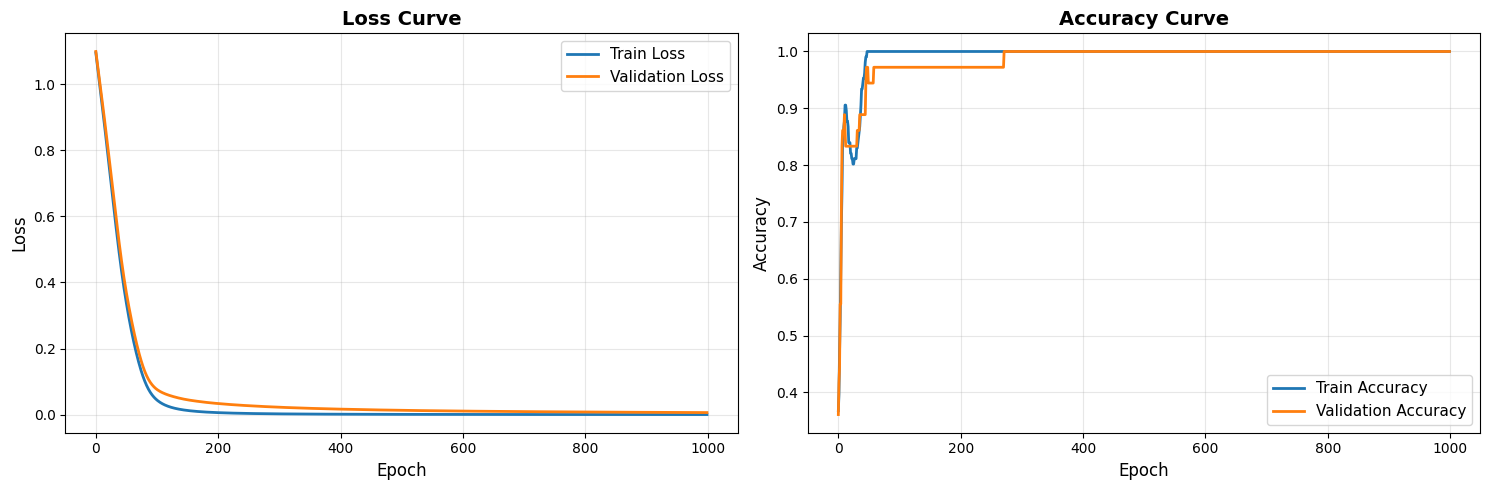


최종 학습 결과
훈련 손실: 0.0002
검증 손실: 0.0062
훈련 정확도: 1.0000 (100.00%)
검증 정확도: 1.0000 (100.00%)


In [33]:
def plot_training_history(history):

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 손실(Loss) 그래프
    axes[0].plot(history['train_losses'], label='Train Loss', linewidth=2)
    axes[0].plot(history['val_losses'], label='Validation Loss', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Loss Curve', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # 정확도(Accuracy) 그래프
    axes[1].plot(history['train_accs'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history['val_accs'], label='Validation Accuracy', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Accuracy Curve', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 최종 결과 출력
    print("\n" + "=" * 50)
    print("최종 학습 결과")
    print("=" * 50)
    print(f"훈련 손실: {history['train_losses'][-1]:.4f}")
    print(f"검증 손실: {history['val_losses'][-1]:.4f}")
    print(f"훈련 정확도: {history['train_accs'][-1]:.4f} ({history['train_accs'][-1]*100:.2f}%)")
    print(f"검증 정확도: {history['val_accs'][-1]:.4f} ({history['val_accs'][-1]*100:.2f}%)")
    print("=" * 50)

# 학습 과정 시각화
plot_training_history(history)

In [34]:
def test_model(model, inputs_test, labels_test):
    test_loss, test_acc = evaluate_model(model, inputs_test, labels_test)

    print(f'테스트 손실: {test_loss:.4f}')
    print(f'테스트 정확도: {test_acc:.4f} ({test_acc*100:.2f}%)')

    # 클래스 별 예측 결과
    model.eval()
    with torch.no_grad():
        outputs = model(inputs_test)
        _, predicted = torch.max(outputs, 1)

    # 클래스 별 정확도 계산
    for class_idx in range(3):
        class_mask = (labels_test == class_idx)
        class_correct = (predicted[class_mask] == labels_test[class_mask]).sum().item()
        class_total = class_mask.sum().item()
        class_accuracy = class_correct / class_total if class_total > 0 else 0
        print(f'클래스: {class_idx}, 정확도: {class_accuracy:.4f}')

In [35]:
# 테스트 평가
test_model(model, inputs_test, labels_test)

테스트 손실: 0.0786
테스트 정확도: 0.9722 (97.22%)
클래스: 0, 정확도: 1.0000
클래스: 1, 정확도: 1.0000
클래스: 2, 정확도: 0.9000
